Bob's Case

We will be working on this for the first three sessions:
1. Introduction
2. Data Wrangling
3. Linear Regression

Shortcuts: 
1. For a box to be text: M
2. For a box to be code: C - Y
To make more boxes:
1. Above: A
2. Below: B

In [1]:
# =========================================================
# STEP 1: LOAD THE DATASETS AND JOIN THEM
# =========================================================

import pandas as pd
import numpy as np

# Optional display settings for readability
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ---------------------------------------------------------
# 1A. Load the CSV files
# ---------------------------------------------------------
sales = pd.read_csv("sales.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

# ---------------------------------------------------------
# 1B. Quick check of the datasets
# ---------------------------------------------------------
print("Sales shape:", sales.shape)
print("Features shape:", features.shape)
print("Stores shape:", stores.shape)

print("\nSales columns:")
print(sales.columns.tolist())

print("\nFeatures columns:")
print(features.columns.tolist())

print("\nStores columns:")
print(stores.columns.tolist())

# ---------------------------------------------------------
# 1C. Convert Date columns to datetime format
# ---------------------------------------------------------
sales["Date"] = pd.to_datetime(sales["Date"])
features["Date"] = pd.to_datetime(features["Date"])

# ---------------------------------------------------------
# 1D. Join sales with features
# Keys available in common: Store, Date, IsHoliday
# ---------------------------------------------------------
df = pd.merge(
    sales,
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

# ---------------------------------------------------------
# 1E. Join the result with stores
# Key available in common: Store
# ---------------------------------------------------------
df = pd.merge(
    df,
    stores,
    on="Store",
    how="left"
)

# ---------------------------------------------------------
# 1F. Final check
# ---------------------------------------------------------
print("\nJoined dataset shape:", df.shape)
print("\nFirst 5 rows of joined dataset:")
print(df.head())

Sales shape: (421570, 5)
Features shape: (8190, 12)
Stores shape: (45, 3)

Sales columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

Features columns:
['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

Stores columns:
['Store', 'Type', 'Size']

Joined dataset shape: (421570, 16)

First 5 rows of joined dataset:
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05     24,924.50      False        42.31        2.57   
1      1     1 2010-02-12     46,039.49       True        38.51        2.55   
2      1     1 2010-02-19     41,595.55      False        39.93        2.51   
3      1     1 2010-02-26     19,403.54      False        46.63        2.56   
4      1     1 2010-03-05     21,827.90      False        46.50        2.62   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5    CPI  Unemployment  \
0        NaN        

In [2]:
# =========================================================
# STEP 2: CLEAN THE DATA
# =========================================================

# Make a copy so the original joined dataset stays untouched
data = df.copy()

# ---------------------------------------------------------
# 2A. Check missing values
# ---------------------------------------------------------
print("Missing values before cleaning:")
print(data.isnull().sum().sort_values(ascending=False))

# ---------------------------------------------------------
# 2B. Remove duplicate rows if any
# ---------------------------------------------------------
data = data.drop_duplicates()

# ---------------------------------------------------------
# 2C. Make variable formats consistent
# ---------------------------------------------------------
# Convert store and department to integer
data["Store"] = data["Store"].astype(int)
data["Dept"] = data["Dept"].astype(int)

# Convert IsHoliday to integer (0/1) for easier analysis/correlation
data["IsHoliday"] = data["IsHoliday"].astype(int)

# Ensure Type is categorical / string
data["Type"] = data["Type"].astype(str)

# ---------------------------------------------------------
# 2D. Handle missing values
# ---------------------------------------------------------
# In this dataset, MarkDown variables are often missing because
# promotions were not active or not recorded. A common simple choice
# is to replace these missing values with 0.
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

for col in markdown_cols:
    data[col] = data[col].fillna(0)

# CPI and Unemployment have some missing values.
# For a simple and transparent approach, fill them with the median
# within each Store. If something is still missing, use the global median.
for col in ["CPI", "Unemployment"]:
    data[col] = data.groupby("Store")[col].transform(lambda x: x.fillna(x.median()))
    data[col] = data[col].fillna(data[col].median())

# ---------------------------------------------------------
# 2E. Drop rows that still have missing values in critical variables
# ---------------------------------------------------------
critical_cols = ["Store", "Dept", "Date", "Weekly_Sales", "Type", "Size"]
data = data.dropna(subset=critical_cols)

# ---------------------------------------------------------
# 2F. Create useful time variables
# ---------------------------------------------------------
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Week"] = data["Date"].dt.isocalendar().week.astype(int)

# ---------------------------------------------------------
# 2G. Final cleaning check
# ---------------------------------------------------------
print("Missing values after cleaning:")
print(data.isnull().sum().sort_values(ascending=False))

print("\nCleaned dataset shape:", data.shape)
print("\nData types:")
print(data.dtypes)

Missing values before cleaning:
MarkDown2       310322
MarkDown4       286603
MarkDown3       284479
MarkDown1       270889
MarkDown5       270138
Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64
Missing values after cleaning:
Store           0
MarkDown4       0
Month           0
Year            0
Size            0
Type            0
Unemployment    0
CPI             0
MarkDown5       0
MarkDown3       0
Dept            0
MarkDown2       0
MarkDown1       0
Fuel_Price      0
Temperature     0
IsHoliday       0
Weekly_Sales    0
Date            0
Week            0
dtype: int64

Cleaned dataset shape: (421570, 19)

Data types:
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                in

Overall summary statistics:
            Store       Dept                           Date  Weekly_Sales  \
count  421,570.00 421,570.00                         421570    421,570.00   
unique        NaN        NaN                            NaN           NaN   
top           NaN        NaN                            NaN           NaN   
freq          NaN        NaN                            NaN           NaN   
mean        22.20      44.26  2011-06-18 08:30:31.963375104     15,981.26   
min          1.00       1.00            2010-02-05 00:00:00     -4,988.94   
25%         11.00      18.00            2010-10-08 00:00:00      2,079.65   
50%         22.00      37.00            2011-06-17 00:00:00      7,612.03   
75%         33.00      74.00            2012-02-24 00:00:00     20,205.85   
max         45.00      99.00            2012-10-26 00:00:00    693,099.36   
std         12.79      30.49                            NaN     22,711.18   

        IsHoliday  Temperature  Fuel_Price  Mar

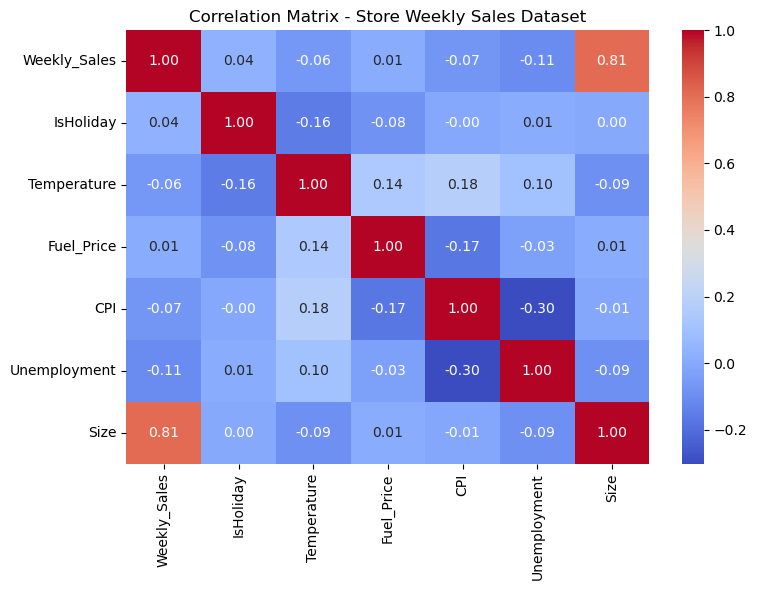

In [4]:
# =========================================================
# STEP 3: EXPLORE THE DATA
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 3A. Overall summary statistics
# ---------------------------------------------------------
print("Overall summary statistics:")
print(data.describe(include="all"))

# ---------------------------------------------------------
# 3B. Summary statistics by store
# ---------------------------------------------------------
store_summary = (
    data.groupby("Store")["Weekly_Sales"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values(by="mean", ascending=False)
)

print("\nSummary statistics of Weekly Sales by Store:")
print(store_summary)

# ---------------------------------------------------------
# 3C. Store 10 summary statistics
# ---------------------------------------------------------
store10 = data[data["Store"] == 10]

print("\nSummary statistics for Store 10:")
print(store10.describe())

# ---------------------------------------------------------
# 3D. Aggregate to store-week level for easier store comparison
# Since sales.csv is at Store-Dept-Date level, it helps to aggregate
# to total weekly sales per store.
# ---------------------------------------------------------
weekly_store_sales = (
    data.groupby(["Store", "Date"], as_index=False)
    .agg(
        Weekly_Sales=("Weekly_Sales", "sum"),
        IsHoliday=("IsHoliday", "max"),
        Temperature=("Temperature", "mean"),
        Fuel_Price=("Fuel_Price", "mean"),
        CPI=("CPI", "mean"),
        Unemployment=("Unemployment", "mean"),
        Size=("Size", "first")
    )
)

print("\nStore-week level dataset:")
print(weekly_store_sales.head())

# ---------------------------------------------------------
# 3E. Correlation matrix
# Use numeric variables only
# ---------------------------------------------------------
corr_data = weekly_store_sales[[
    "Weekly_Sales", "IsHoliday", "Temperature",
    "Fuel_Price", "CPI", "Unemployment", "Size"
]]

corr_matrix = corr_data.corr()

print("\nCorrelation matrix:")
print(corr_matrix)

# ---------------------------------------------------------
# 3F. Plot the correlation matrix
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix - Store Weekly Sales Dataset")
plt.tight_layout()
plt.show()

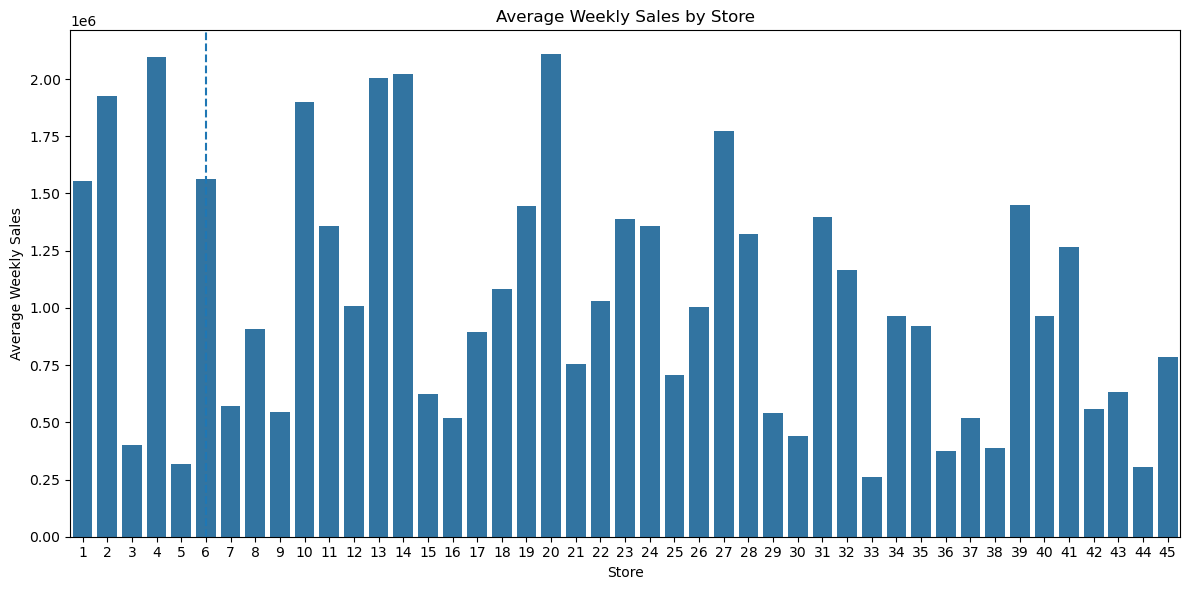

Store 10 average weekly sales and rank:
   Store  Weekly_Sales  Rank
9     10  1,899,424.57  6.00


In [5]:
# =========================================================
# STEP 4: VISUALS FOR STORE 10 PERFORMANCE
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 4A. Compare average weekly sales of Store 10 vs all stores
# ---------------------------------------------------------
avg_sales_by_store = (
    weekly_store_sales.groupby("Store", as_index=False)["Weekly_Sales"]
    .mean()
    .sort_values("Weekly_Sales", ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_sales_by_store, x="Store", y="Weekly_Sales")
plt.axvline(x=list(avg_sales_by_store["Store"]).index(10), linestyle="--")
plt.title("Average Weekly Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Print Store 10 rank
avg_sales_by_store["Rank"] = avg_sales_by_store["Weekly_Sales"].rank(ascending=False, method="min")
store10_rank = avg_sales_by_store.loc[avg_sales_by_store["Store"] == 10, ["Store", "Weekly_Sales", "Rank"]]
print("Store 10 average weekly sales and rank:")
print(store10_rank)

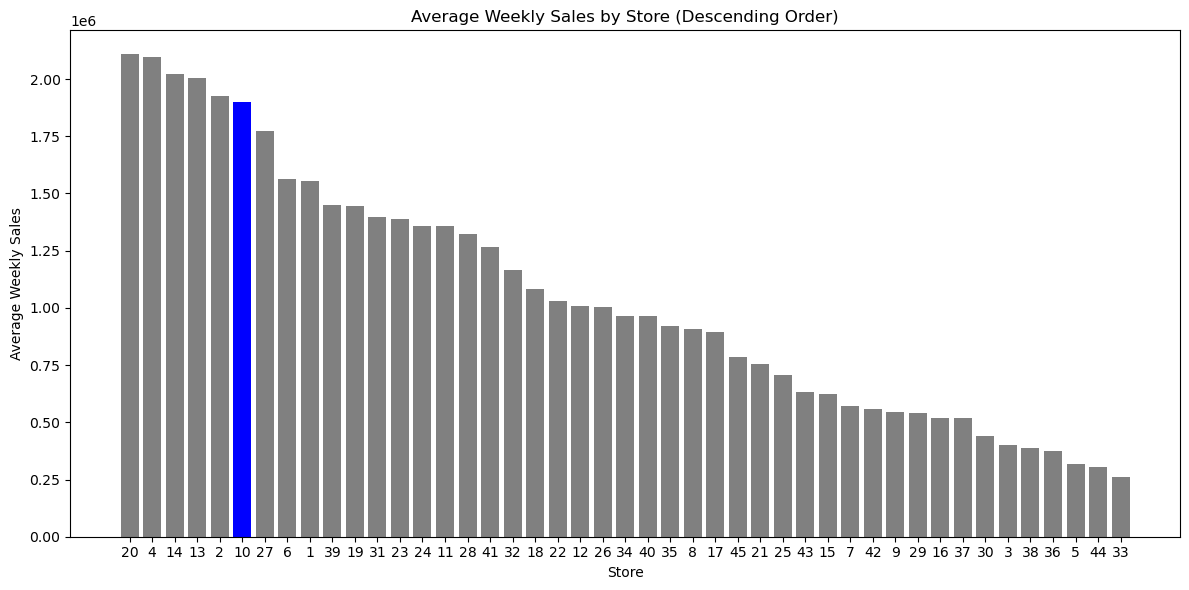

Store 10 performance:
   Store  Weekly_Sales  Rank
9     10  1,899,424.57  6.00


In [6]:
# ---------------------------------------------------------
# 4A (Corrected). Average weekly sales by store
# Sorted descending + highlight Store 10
# ---------------------------------------------------------

# Sort stores by average weekly sales (descending)
avg_sales_by_store = (
    weekly_store_sales.groupby("Store", as_index=False)["Weekly_Sales"]
    .mean()
    .sort_values("Weekly_Sales", ascending=False)
)

# Create color mapping: blue for Store 10, gray for others
colors = [
    "blue" if store == 10 else "gray"
    for store in avg_sales_by_store["Store"]
]

# Plot
plt.figure(figsize=(12, 6))
plt.bar(
    avg_sales_by_store["Store"].astype(str),  # convert to string for clean x-axis
    avg_sales_by_store["Weekly_Sales"],
    color=colors
)

plt.title("Average Weekly Sales by Store (Descending Order)")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Optional: print Store 10 rank clearly
avg_sales_by_store["Rank"] = avg_sales_by_store["Weekly_Sales"].rank(
    ascending=False, method="min"
)

print("Store 10 performance:")
print(avg_sales_by_store[avg_sales_by_store["Store"] == 10])

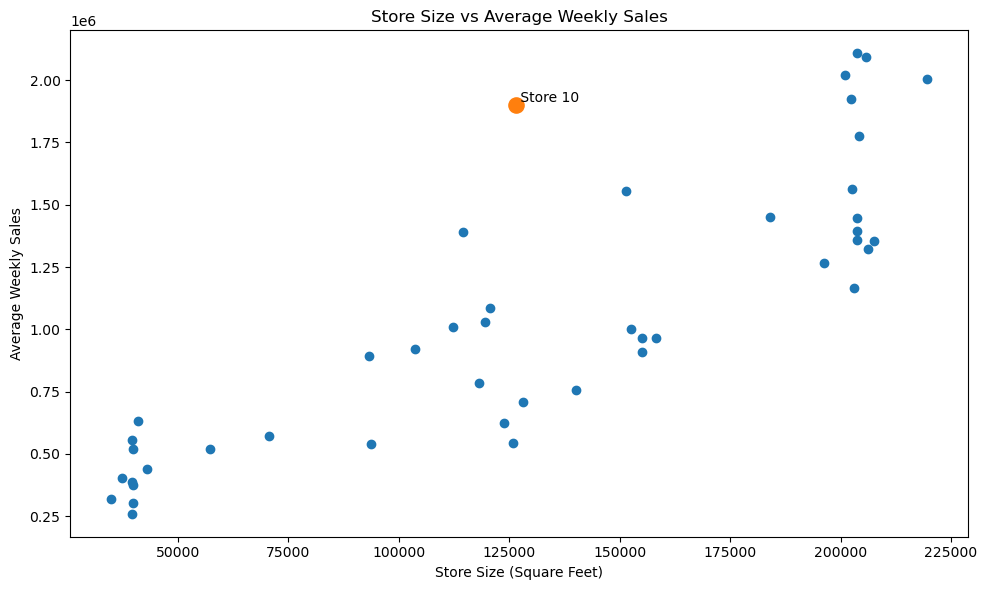

In [7]:
# ---------------------------------------------------------
# 4G. Store Size vs Average Weekly Sales (Highlight Store 10)
# ---------------------------------------------------------

# Aggregate to store-level (average weekly sales per store)
store_level = (
    weekly_store_sales.groupby("Store", as_index=False)
    .agg(
        Avg_Weekly_Sales=("Weekly_Sales", "mean"),
        Size=("Size", "first")
    )
)

# Separate Store 10
store10_point = store_level[store_level["Store"] == 10]
other_stores = store_level[store_level["Store"] != 10]

# Plot
plt.figure(figsize=(10, 6))

# Plot other stores in gray
plt.scatter(
    other_stores["Size"],
    other_stores["Avg_Weekly_Sales"]
)

# Plot Store 10 in blue (highlight)
plt.scatter(
    store10_point["Size"],
    store10_point["Avg_Weekly_Sales"],
    s=120  # larger point for emphasis
)

# Annotate Store 10
for _, row in store10_point.iterrows():
    plt.text(
        row["Size"],
        row["Avg_Weekly_Sales"],
        " Store 10",
        verticalalignment="bottom"
    )

plt.title("Store Size vs Average Weekly Sales")
plt.xlabel("Store Size (Square Feet)")
plt.ylabel("Average Weekly Sales")

plt.tight_layout()
plt.show()